In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv("citrus.csv")
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [ ]:
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
df['name'] = df['name'].replace({
    0: 'Orange',
    1: 'Grapefruit'
})

In [ ]:
df['name'].value_counts()

,count
name,
orange,5000
grapefruit,5000


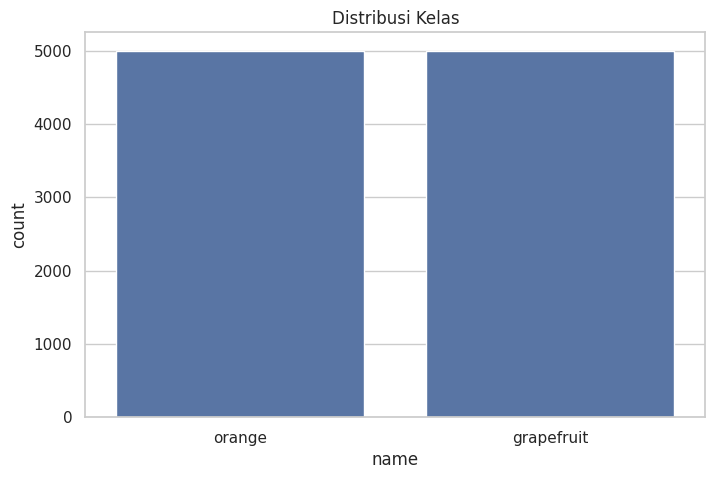

In [ ]:
sns.countplot(x='name', data=df)
plt.title("Distribusi Kelas")
plt.show()

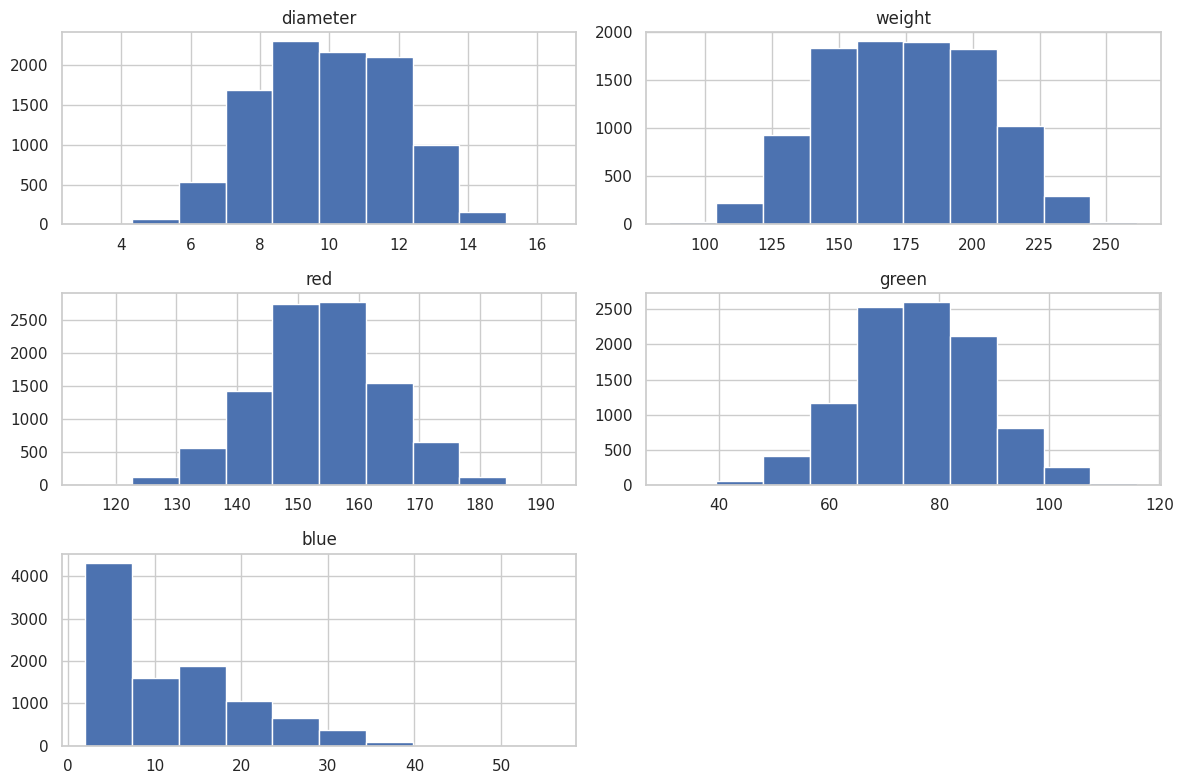

In [ ]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

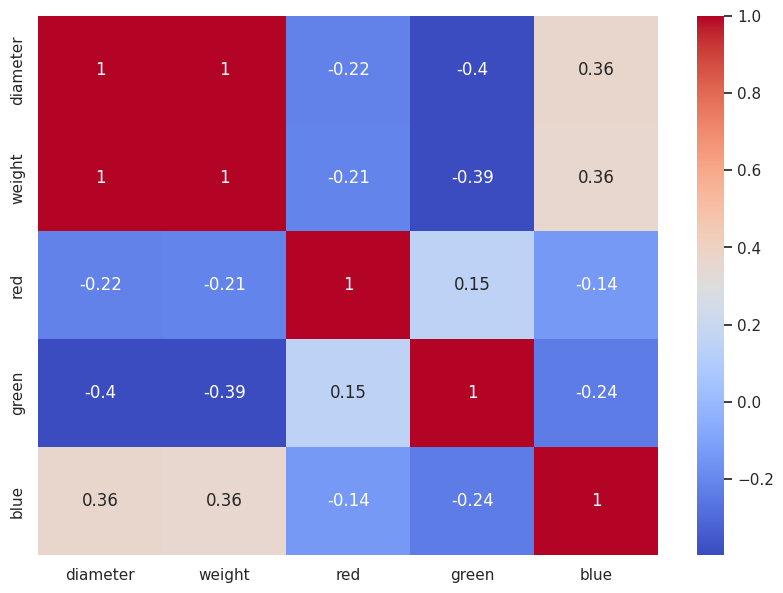

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.drop('name', axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
le = LabelEncoder()
df['name'] = le.fit_transform(df['name'])

In [ ]:
X = df.drop('name', axis=1)
y = df['name']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

Accuracy: 0.9475
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1000
           1       0.94      0.95      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))

Accuracy: 0.926
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1000
           1       0.93      0.92      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



In [ ]:
svm = SVC()
svm.fit(X_train_scaled, y_train)

pred_svm = svm.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

Accuracy: 0.9395
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1000
           1       0.95      0.93      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



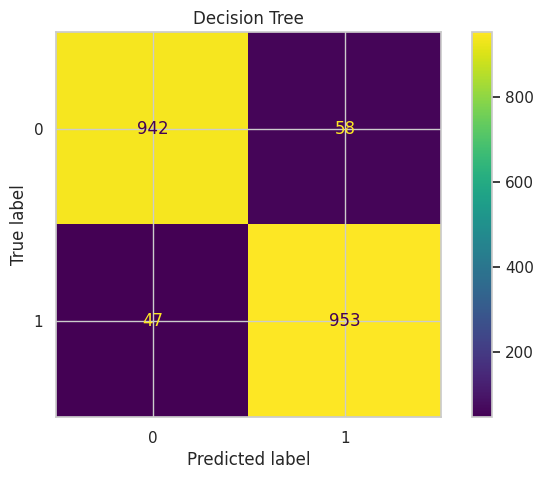

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_dt)
plt.title("Decision Tree")
plt.show()

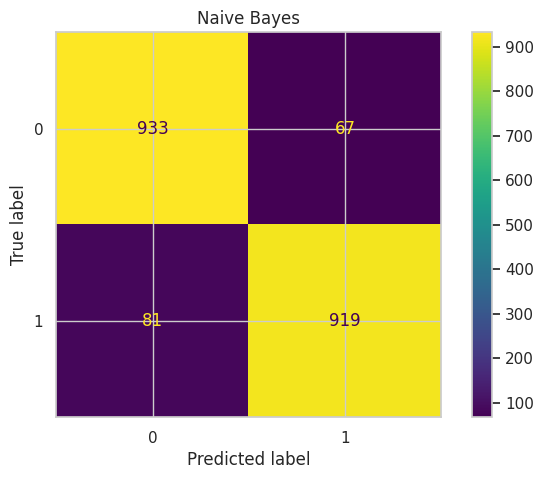

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_nb)
plt.title("Naive Bayes")
plt.show()

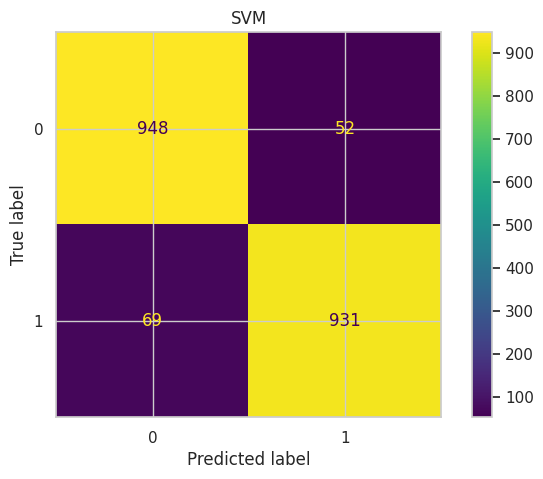

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_svm)
plt.title("SVM")
plt.show()

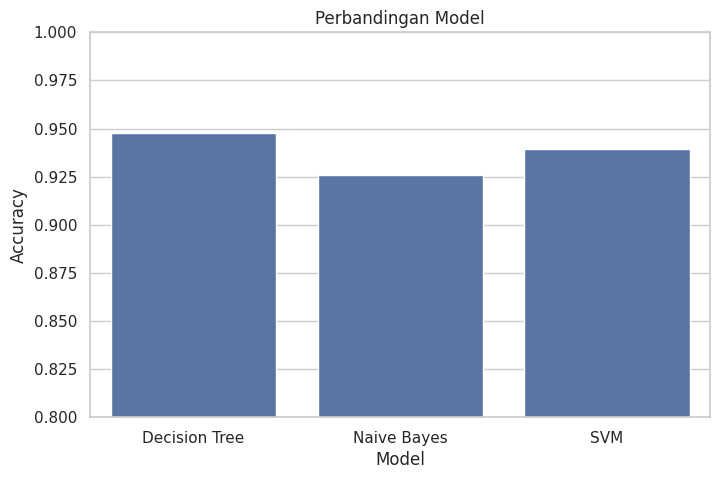

In [ ]:
hasil = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_svm)
    ]
})
sns.barplot(x='Model', y='Accuracy', data=hasil)
plt.ylim(0.8,1.0)
plt.title("Perbandingan Model")
plt.show()

In [ ]:
hasil.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
0,Decision Tree,0.9475
2,SVM,0.9395
1,Naive Bayes,0.9260
